# Fase 7 — Postprocesamiento y dashboard

Simulacion completa del sistema AIB (motor + mecanismo + sarta + bomba) con generacion de todos los outputs operativos: cartas dinamometricas, torque, potencia, caudal y eficiencia.

In [1]:
import sys, os, time
sys.path.insert(0, os.path.abspath('..'))

import numpy as np
import matplotlib.pyplot as plt
from aib_simulator import params as P
from aib_simulator.coupling import Simulator

%matplotlib inline

# Parametros del sistema
sim_params = {k: getattr(P, k) for k in dir(P) if not k.startswith('_') and not callable(getattr(P, k))}

# Correr simulacion completa: 20 ciclos (~150s)
sim = Simulator(sim_params, motor_model='linear')
sim.initialize(theta_0=0.0, omega_0_crank=2*np.pi*8.0/60)

n_total = int(20 * 60.0 / 8.0 / P.dt)
keys = ['theta', 'omega', 'y_PR', 'F_PR', 'TF', 'T_motor_crank',
        'T_gearbox', 'T_cw', 'F_pump', 'q_inst', 'omega_m']
R = {k: np.zeros(n_total) for k in keys}

t0 = time.time()
for step in range(n_total):
    state = sim.step()
    for k in keys:
        R[k][step] = state[k]
elapsed = time.time() - t0
print(f"Simulacion: {n_total} pasos en {elapsed:.1f}s")

# Identificar ultimo ciclo completo
theta_mod = R['theta'] % (2*np.pi)
crossings = np.where(np.diff(theta_mod) < -np.pi)[0]
if len(crossings) >= 2:
    i0, i1 = crossings[-2], crossings[-1]
else:
    n_est = int(60/9.5/P.dt)
    i0, i1 = n_total-n_est, n_total-1

# Extraer ultimo ciclo
sl = slice(i0, i1)
theta_c = R['theta'][sl] % (2*np.pi)
omega_c = R['omega'][sl]
y_c = R['y_PR'][sl]
F_c = R['F_PR'][sl]
Tgb_c = R['T_gearbox'][sl]
Tmc_c = R['T_motor_crank'][sl]
Fp_c = R['F_pump'][sl]
q_c = R['q_inst'][sl]
om_m_c = R['omega_m'][sl]

# Metricas globales
SPM_avg = R['theta'][-1]/(2*np.pi) / (n_total*P.dt/60)
PPRL = np.max(F_c)
MPRL = np.min(F_c)
stroke = np.max(y_c) - np.min(y_c)
omega_mean = np.mean(omega_c)
omega_var = (np.max(omega_c)-np.min(omega_c))/omega_mean*100
T_peak = np.max(np.abs(Tgb_c))
P_motor = om_m_c * Tmc_c / P.N_total
P_avg = np.mean(P_motor)
q_avg_m3d = np.mean(R['q_inst'][-3*(i1-i0):]) * 86400 * P.dt / (60/SPM_avg)
# Correccion: caudal promedio por ciclo
q_total_last3 = np.sum(R['q_inst'][-3*(i1-i0):]) * P.dt
t_last3 = 3*(i1-i0)*P.dt
q_avg_m3d = q_total_last3 / t_last3 * 86400

print(f"SPM = {SPM_avg:.2f}, Stroke = {stroke:.3f} m")

Simulacion: 69767 pasos en 2.9s
SPM = 9.78, Stroke = 2.888 m


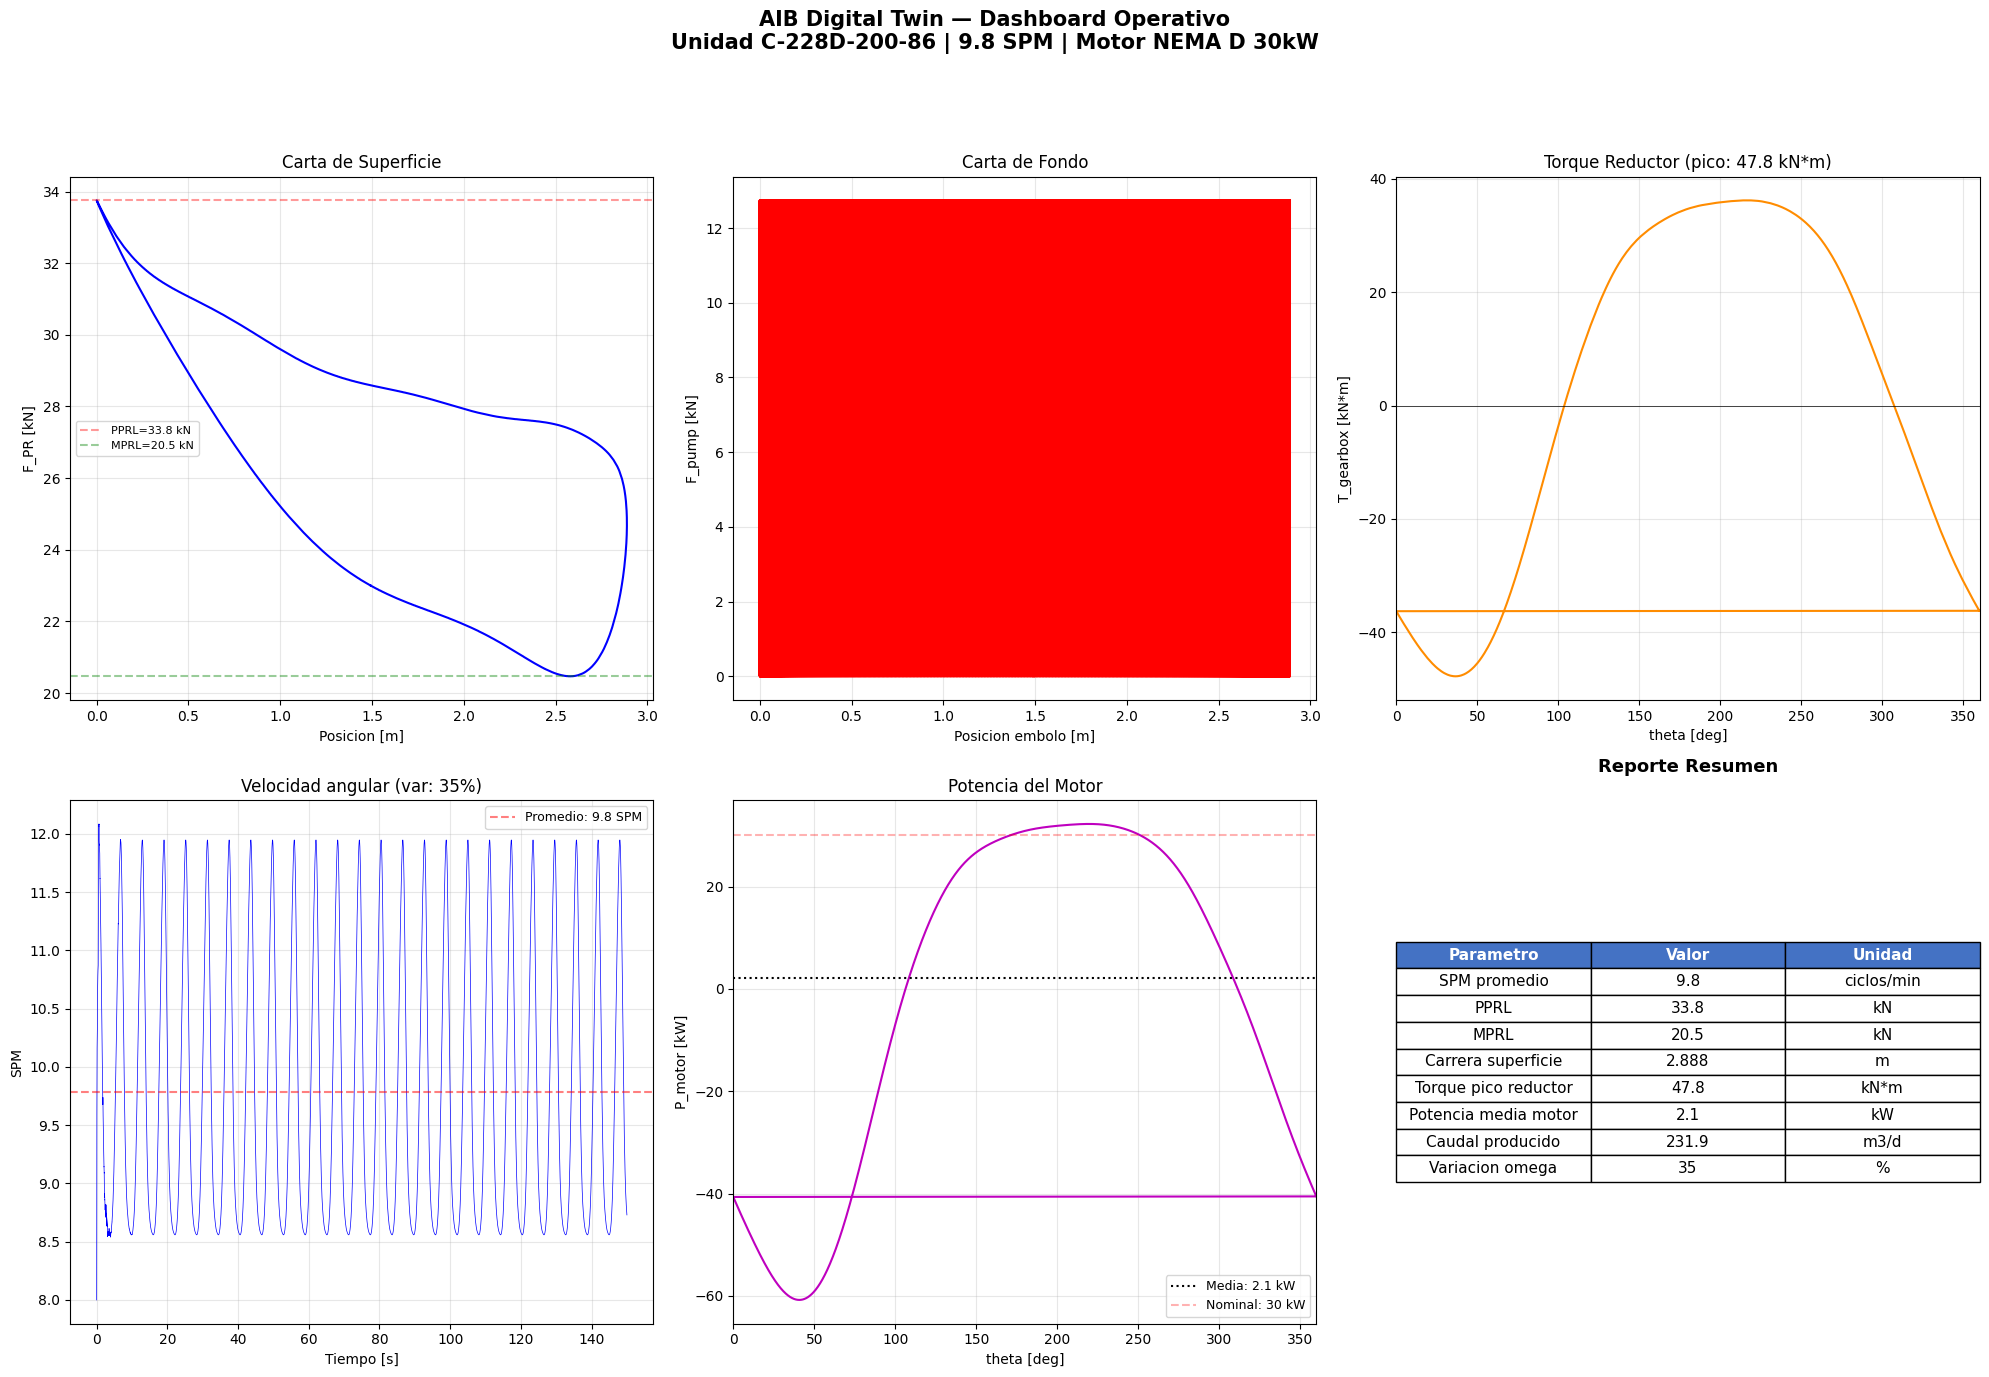


SIMULACION COMPLETA — TODAS LAS FASES IMPLEMENTADAS


In [2]:
# ====================================================================
# DASHBOARD FINAL
# ====================================================================
fig = plt.figure(figsize=(20, 14))
fig.suptitle('AIB Digital Twin — Dashboard Operativo\n'
             f'Unidad C-228D-200-86 | {SPM_avg:.1f} SPM | Motor NEMA D 30kW',
             fontsize=15, fontweight='bold')

# 1. Carta dinamometrica de superficie
ax1 = fig.add_subplot(2, 3, 1)
y_norm = y_c - np.min(y_c)
ax1.plot(y_norm, F_c/1e3, 'b-', linewidth=1.5)
ax1.axhline(PPRL/1e3, color='r', ls='--', alpha=0.4, label=f'PPRL={PPRL/1e3:.1f} kN')
ax1.axhline(MPRL/1e3, color='g', ls='--', alpha=0.4, label=f'MPRL={MPRL/1e3:.1f} kN')
ax1.set_xlabel('Posicion [m]')
ax1.set_ylabel('F_PR [kN]')
ax1.set_title('Carta de Superficie')
ax1.legend(fontsize=8)
ax1.grid(True, alpha=0.3)

# 2. Carta de fondo
ax2 = fig.add_subplot(2, 3, 2)
u_bot = R['y_PR'][sl]  # aproximar posicion del embolo con y_PR
u_bot_norm = u_bot - np.min(u_bot)
ax2.plot(u_bot_norm, Fp_c/1e3, 'r-', linewidth=1.5)
ax2.set_xlabel('Posicion embolo [m]')
ax2.set_ylabel('F_pump [kN]')
ax2.set_title('Carta de Fondo')
ax2.grid(True, alpha=0.3)

# 3. Torque en reductor
ax3 = fig.add_subplot(2, 3, 3)
ax3.plot(np.degrees(theta_c), Tgb_c/1e3, 'darkorange', linewidth=1.5)
ax3.axhline(0, color='k', linewidth=0.5)
ax3.set_xlabel('theta [deg]')
ax3.set_ylabel('T_gearbox [kN*m]')
ax3.set_title(f'Torque Reductor (pico: {T_peak/1e3:.1f} kN*m)')
ax3.set_xlim(0, 360)
ax3.grid(True, alpha=0.3)

# 4. Velocidad angular
ax4 = fig.add_subplot(2, 3, 4)
t_arr = np.arange(n_total) * P.dt
ax4.plot(t_arr, R['omega']*60/(2*np.pi), 'b-', linewidth=0.5)
ax4.axhline(SPM_avg, color='r', ls='--', alpha=0.5, label=f'Promedio: {SPM_avg:.1f} SPM')
ax4.set_xlabel('Tiempo [s]')
ax4.set_ylabel('SPM')
ax4.set_title(f'Velocidad angular (var: {omega_var:.0f}%)')
ax4.legend(fontsize=9)
ax4.grid(True, alpha=0.3)

# 5. Potencia motor
ax5 = fig.add_subplot(2, 3, 5)
ax5.plot(np.degrees(theta_c), P_motor/1e3, 'm-', linewidth=1.5)
ax5.axhline(P_avg/1e3, color='k', ls=':', label=f'Media: {P_avg/1e3:.1f} kW')
ax5.axhline(P.P_nom/1e3, color='r', ls='--', alpha=0.3, label=f'Nominal: {P.P_nom/1e3:.0f} kW')
ax5.set_xlabel('theta [deg]')
ax5.set_ylabel('P_motor [kW]')
ax5.set_title('Potencia del Motor')
ax5.set_xlim(0, 360)
ax5.legend(fontsize=9)
ax5.grid(True, alpha=0.3)

# 6. Tabla resumen
ax6 = fig.add_subplot(2, 3, 6)
ax6.axis('off')
summary = [
    ['Parametro', 'Valor', 'Unidad'],
    ['SPM promedio', f'{SPM_avg:.1f}', 'ciclos/min'],
    ['PPRL', f'{PPRL/1e3:.1f}', 'kN'],
    ['MPRL', f'{MPRL/1e3:.1f}', 'kN'],
    ['Carrera superficie', f'{stroke:.3f}', 'm'],
    ['Torque pico reductor', f'{T_peak/1e3:.1f}', 'kN*m'],
    ['Potencia media motor', f'{P_avg/1e3:.1f}', 'kW'],
    ['Caudal producido', f'{q_avg_m3d:.1f}', 'm3/d'],
    ['Variacion omega', f'{omega_var:.0f}', '%'],
]
table = ax6.table(cellText=summary, loc='center', cellLoc='center')
table.auto_set_font_size(False)
table.set_fontsize(11)
table.scale(1, 1.5)
for i in range(len(summary[0])):
    table[0, i].set_facecolor('#4472C4')
    table[0, i].set_text_props(color='white', fontweight='bold')
ax6.set_title('Reporte Resumen', fontsize=13, fontweight='bold', pad=20)

plt.tight_layout(rect=[0, 0, 1, 0.93])
plt.show()

print("\n" + "="*60)
print("SIMULACION COMPLETA — TODAS LAS FASES IMPLEMENTADAS")
print("="*60)